# Suppressed activation steering

This notebook finds one prompt's vocabulary directions that rise in the middle layers and fall
before output. It then replaces that residual-stream component with the component from a second
prompt. Edit the configuration cell and read the dose grid in both directions.

The extraction and intervention functions are the same ones used for Figure 2 in the
[README](../README.md). This is sample-specific: extraction first runs each complete prompt
without intervention.

In [1]:
import os
from pathlib import Path
import subprocess
import sys

ROOT = Path(os.environ.get("SUPPRESSED_ROOT", ".")).resolve()
sys.path.insert(0, str(ROOT))

import torch
from IPython.display import Image, display
from tabulate import tabulate
from transformers import AutoModelForCausalLM, AutoTokenizer

from scripts.demo import generate, intervention_hooks, metrics, one_token, run_forward, trajectory
from suppressed_activation_subspace import suppressed_activation_subspace

# Edit this cell. `just notebook-smoke` overrides the same values with environment variables.
MODEL = os.environ.get("SUPPRESSED_MODEL", "Qwen/Qwen3.5-4B")
DEVICE = os.environ.get("SUPPRESSED_DEVICE", "cuda")
SOURCE_PROMPT = os.environ.get(
    "SUPPRESSED_SOURCE_PROMPT", 'The Chinese translation of the German word "Herz" is "'
)
TARGET_PROMPT = os.environ.get(
    "SUPPRESSED_TARGET_PROMPT", 'The Chinese translation of the German word "Schule" is "'
)
SOURCE_OUTPUT = os.environ.get("SUPPRESSED_SOURCE_OUTPUT", "心")
TARGET_OUTPUT = os.environ.get("SUPPRESSED_TARGET_OUTPUT", "学校")
EARLY_LAYER = int(os.environ.get("SUPPRESSED_EARLY_LAYER", 22))
PEAK_LAYER = int(os.environ.get("SUPPRESSED_PEAK_LAYER", 27))
OUTPUT_LAYER = int(os.environ.get("SUPPRESSED_OUTPUT_LAYER", 32))
INTERVENTION_START = int(os.environ.get("SUPPRESSED_INTERVENTION_START", 23))
INTERVENTION_END = int(os.environ.get("SUPPRESSED_INTERVENTION_END", 30))
RANK = int(os.environ.get("SUPPRESSED_RANK", 8))
MAX_NEW_TOKENS = int(os.environ.get("SUPPRESSED_TOKENS", 64))
STRENGTHS = tuple(
    float(value)
    for value in os.environ.get(
        "SUPPRESSED_STRENGTHS", "-0.5,-0.25,-0.125,0,0.125,0.25,0.5,1,2"
    ).split(",")
)
GIT_DESCRIBE = subprocess.run(
    ["git", "describe", "--always", "--dirty"],
    cwd=ROOT,
    check=True,
    text=True,
    capture_output=True,
).stdout.strip()
{
    "git": GIT_DESCRIBE,
    "model": MODEL,
    "layers": (EARLY_LAYER, PEAK_LAYER, OUTPUT_LAYER),
    "intervention": (INTERVENTION_START, INTERVENTION_END),
    "rank": RANK,
    "strengths": STRENGTHS,
}

/workspace/2026/suppressed-activations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'git': 'v0.1.1-10-gd14da72',
 'model': 'Qwen/Qwen3.5-4B',
 'layers': (22, 27, 32),
 'intervention': (23, 30),
 'rank': 8,
 'strengths': (-0.5, -0.25, -0.125, 0.0, 0.125, 0.25, 0.5, 1.0, 2.0)}

## Load the model and extract both sample-specific subspaces

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)
dtype = torch.bfloat16 if DEVICE == "cuda" else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=dtype).to(DEVICE).eval()
language_model = model.model
blocks = language_model.layers
final_norm = language_model.norm
unembedding = model.lm_head.weight
norm_gain = 1.0 + final_norm.weight

source_ids = tokenizer(SOURCE_PROMPT, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
target_ids = tokenizer(TARGET_PROMPT, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
source_residuals, clean_logits = trajectory(model, source_ids, final_norm)
target_residuals, _ = trajectory(model, target_ids, final_norm)

source_basis, source_selected = suppressed_activation_subspace(
    source_residuals[:, -1][None],
    unembedding,
    norm_gain,
    early_layer=EARLY_LAYER,
    peak_layer=PEAK_LAYER,
    output_layer=OUTPUT_LAYER,
    rank=RANK,
)
target_basis, target_selected = suppressed_activation_subspace(
    target_residuals[:, -1][None],
    unembedding,
    norm_gain,
    early_layer=EARLY_LAYER,
    peak_layer=PEAK_LAYER,
    output_layer=OUTPUT_LAYER,
    rank=RANK,
)
source_basis, target_basis = source_basis[0], target_basis[0]
selected_words = {
    "source": [tokenizer.decode([token_id]) for token_id in source_selected[0]],
    "target": [tokenizer.decode([token_id]) for token_id in target_selected[0]],
}
selected_words

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1199.06it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 426/426 [00:00<00:00, 4740.22it/s]

{'source': [' heart',
  ' hearts',
  ' Heart',
  '-heart',
  ' Cards',
  ' jantung',
  ' cards',
  ' cardiac'],
 'target': [' school',
  ' schools',
  ' scho',
  ' Schools',
  ' szko',
  ' School',
  ' المدرسة',
  'عودة']}

`source_basis @ source_basis.T` and `target_basis @ target_basis.T` are projectors. The
replacement removes the source component, adds the target component at the same norm, and restores
the residual norm. It does not pair individual QR columns.

In [3]:
blocks_to_hook = range(INTERVENTION_START - 1, INTERVENTION_END)
source_output_id = one_token(tokenizer, SOURCE_OUTPUT)
target_output_id = one_token(tokenizer, TARGET_OUTPUT)


def hooks(strength: float):
    if strength == 0:
        return {}
    return intervention_hooks(
        source_basis,
        target_basis,
        target_residuals,
        operation="replace",
        strength=strength,
        blocks_to_hook=blocks_to_hook,
    )

## Sweep both directions

Positive strength moves from the source component toward the target component. Negative strength
moves in the opposite direction. The useful range is local: excessive intervention can repeat,
change task format, or become malformed, so the grid includes weak and excessive strengths.

In [4]:
print(
    f"Positive C moves source → target at residual layers "
    f"L{INTERVENTION_START}–L{INTERVENTION_END}."
)
metric_rows = []
for strength in STRENGTHS:
    logits = clean_logits if strength == 0 else run_forward(model, source_ids, blocks, hooks(strength))
    row = metrics(tokenizer, logits, clean_logits, source_output_id, target_output_id)
    metric_rows.append(
        {
            "strength C": strength,
            "top token": row["top"][0]["token"],
            f"p({SOURCE_OUTPUT})": row["p_source"],
            f"p({TARGET_OUTPUT})": row["p_target"],
            "target/source log odds": row["log_odds_target_vs_source"],
            "KL from clean": row["kl_from_clean"],
        }
    )
print(tabulate(metric_rows, headers="keys", tablefmt="rounded_outline", floatfmt="+.4f"))

Positive C moves source → target at residual layers L23–L30.


╭──────────────┬─────────────┬─────────┬───────────┬──────────────────────────┬─────────────────╮
│   strength C │ top token   │   p(心) │   p(学校) │   target/source log odds │   KL from clean │
├──────────────┼─────────────┼─────────┼───────────┼──────────────────────────┼─────────────────┤
│      -0.5000 │ _           │ +0.0000 │   +0.0000 │                 -22.4531 │        +14.1655 │
│      -0.2500 │ _           │ +0.0106 │   +0.0000 │                 -21.5625 │         +3.5283 │
│      -0.1250 │ 心          │ +0.6405 │   +0.0000 │                 -19.4531 │         +0.1032 │
│      +0.0000 │ 心          │ +0.5609 │   +0.0000 │                 -12.8281 │         +0.0000 │
│      +0.1250 │ 心          │ +0.4564 │   +0.0004 │                  -7.1250 │         +0.0451 │
│      +0.2500 │ 心          │ +0.4205 │   +0.0060 │                  -4.2500 │         +0.1493 │
│      +0.5000 │ 心          │ +0.2518 │   +0.0411 │                  -1.8125 │         +0.5735 │
│      +1.0000 │ 学校        │

In [5]:
generation_rows = []
for strength in STRENGTHS:
    result = generate(
        model,
        tokenizer,
        source_ids,
        blocks,
        hooks(strength),
        max_new_tokens=MAX_NEW_TOKENS,
    )
    generation_rows.append({"strength C": strength, "generation": result["text"]})
print(
    tabulate(
        generation_rows,
        headers="keys",
        tablefmt="grid",
        floatfmt="+.3f",
        maxcolwidths=[8, 110],
    )
)

+--------------+----------------------------------------------------------------------------------------------------------------+
|   strength C | generation                                                                                                     |
+==============+================================================================================================================+
|       -0.500 | _ jantung_ jantung__". This translation is hearts. The German hearts translation is "____ jantung_ jantung-    |
|              | heart_". The German translation of the word "_ jantung_ jantung__ jantung_ jantung_ jantung_ jantung_ jantung_ |
|              | jantung_ jantung_ jantung_ jantung_ jantung_ jantung_ jantung                                                  |
+--------------+----------------------------------------------------------------------------------------------------------------+
|       -0.250 | _".                                                                      

## The measured replacement and controls

Figure 2 uses a prompt-only `C=1` replacement, source-component removal, and 32 random rank-8
replacements matched for residual norm and perturbation norm. The notebook grid above instead
keeps the hook active during generation so that excessive strengths are visible.

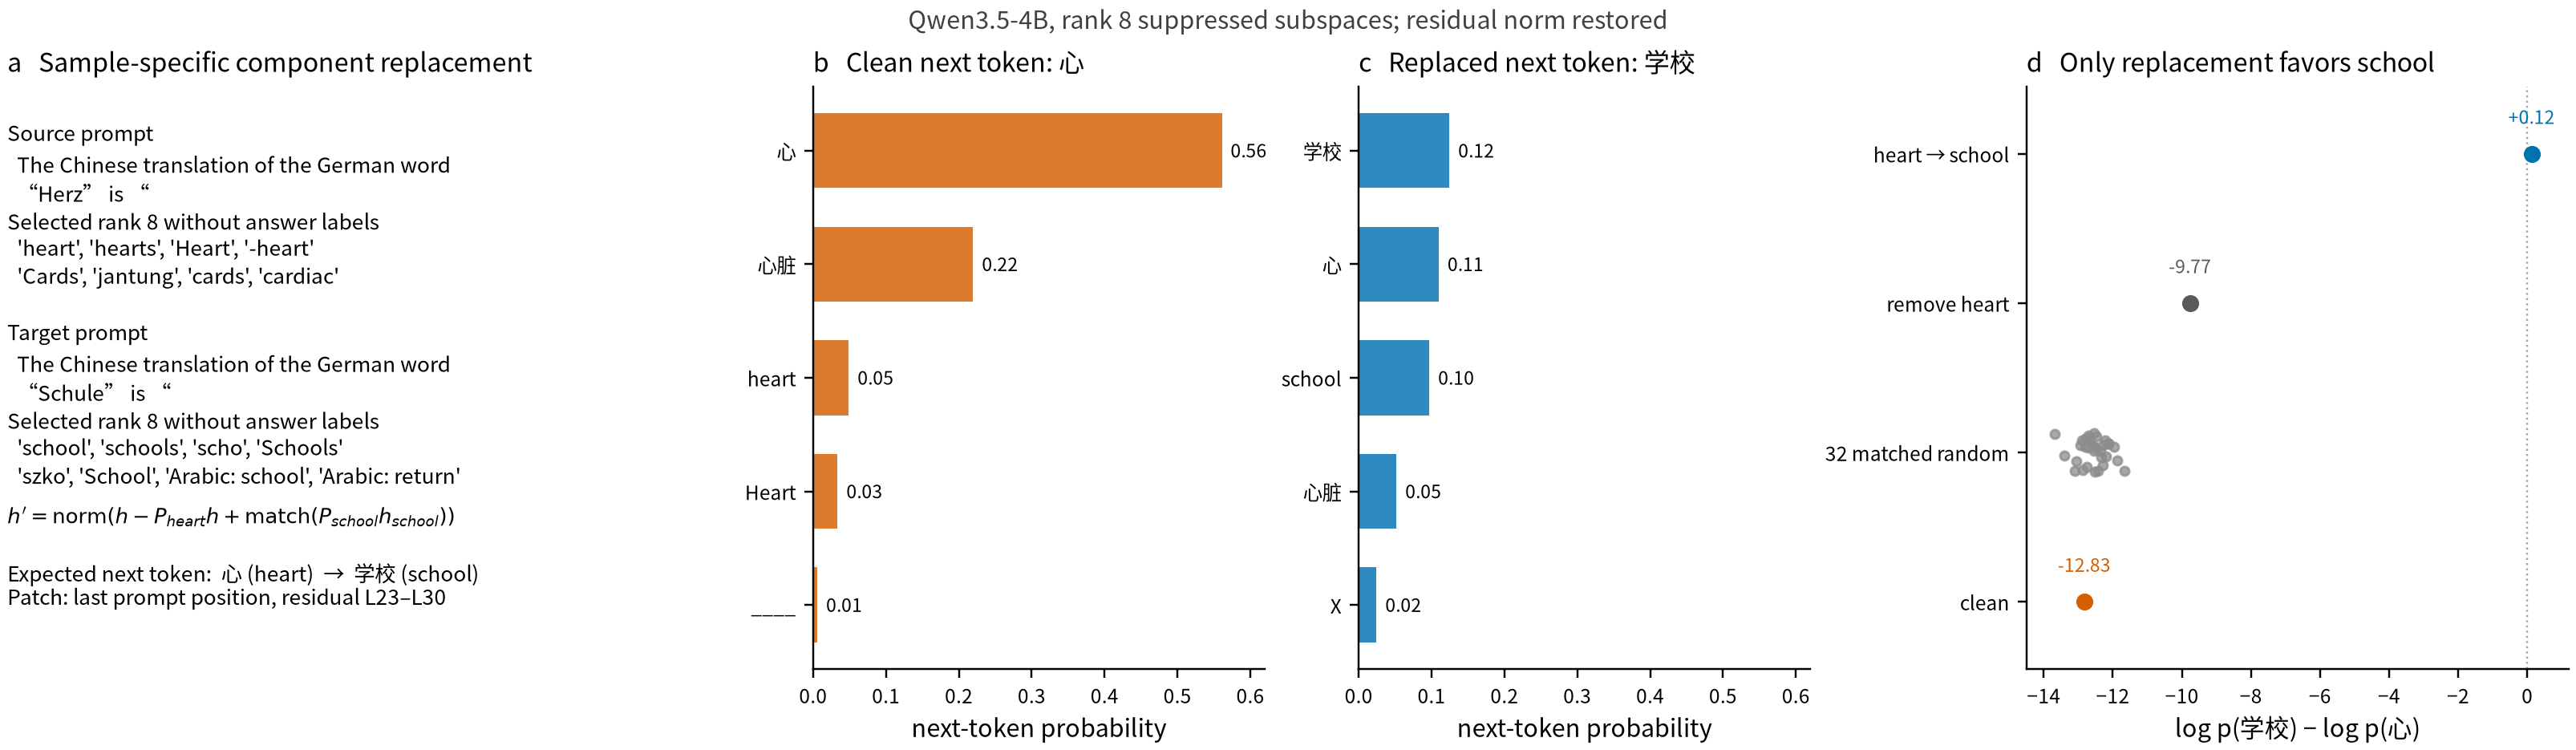

In [6]:
display(Image(filename=ROOT / "figs/causal_demo.png"))

<!-- Notebook drafted by PI/gpt-5.4 from Michael J. Clark's requested demo structure. -->